In [1]:
import dasly
from dasly.fitting.hyperbola_fitter import (
    fit_multiple_hyperbolas_least_squares,
    derive_hyperbola_metrics,
)
from dasly.execution.box_saver import build_box_df
from dasly.loader.fsearcher import parse_file_path


# Parameters


In [2]:
file_paths = [
    '../data/svalbard/20220822/dphi/122539.hdf5',
    '../data/svalbard/20220822/dphi/122549.hdf5',
    '../data/svalbard/20220822/dphi/122559.hdf5',
]
s_start, s_end = 5_000, 115_000  # Start and end channel indices
f_min, f_max = 15, 25  # Hz
v_min, v_max = 1_484, 1_4844  # m/s
rms_window_size = 0.5  # Window size for RMS calculation in seconds
train_size = (640, 640)  # Training size in pixels
# This is fixed for the pretrained model fin_whale_detection_weights.pt
train_physical = (110_000, 30)  # Training size in physical units (m, s)
# This is fixed for the pretrained model fin_whale_detection_weights.pt
grayscale_by_column = True  # Grayscale transform by column
model_path = '../models/fin_whale_detection_weights.pt'
yolo_iou = 0.25  # Reverse data for YOLO model
hyperbolas_num_points = 10  # Number of binary transformed points preserved
# for hyperbola fitting
hyperbolas_by_channel = True  # Binary transformed points by channel
# for hyperbola fitting


# Detection



0: 640x640 7 fin_whales, 17.6ms
Speed: 2.6ms preprocess, 17.6ms inference, 4.3ms postprocess per image at shape (1, 3, 640, 640)


vmax: 194


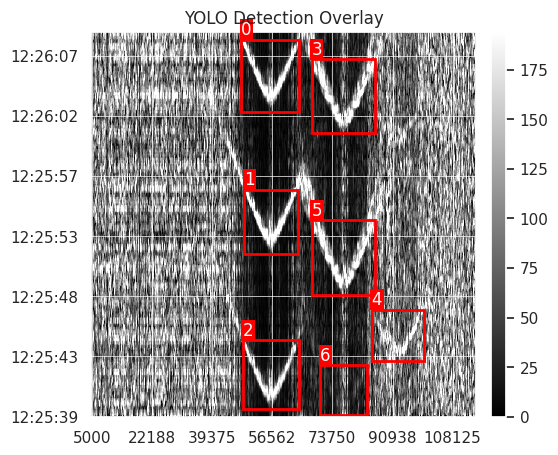

In [3]:
das_rms = (
    dasly.DASArray()
    .load(file_paths=file_paths, s_start=s_start, s_end=s_end)
    .fk_filter_real(f_min=f_min, f_max=f_max, v_min=v_min, v_max=v_max)
    .rms(window_size_second=rms_window_size)
)

das = (
    das_rms
    .match_train_scale(
        # This is fixed for the pretrained model fin_whale_detection_weights.pt
        train_ds=train_physical[0] / train_size[0],
        train_dt=train_physical[1] / train_size[1]
    )
    .grayscale_transform(by_column=grayscale_by_column)
    .rgb_transform()
    .yolo(model=model_path, iou=yolo_iou)
)

fig, ax = das.plot(
    title='YOLO Detection Overlay',
    xlabel='',
    ylabel='',
    colorbar_label=''
)

dasly.add_boxes(fig, das.meta.boxesn, num_boxes=True)


# Detection Boxes Information


In [4]:
hyperbolas = fit_multiple_hyperbolas_least_squares(
    array=das_rms,
    boxesn=das.meta.boxesn,
    num_points=hyperbolas_num_points,
    by_channel=hyperbolas_by_channel
)

hyper_metrics = derive_hyperbola_metrics(
    hyperbolas=hyperbolas,
    ds=das_rms.meta.ds,
    dx=das_rms.meta.dx
)

exp_path, yyyymmdd, hhmmss, hhmmss_hdf5 = parse_file_path(file_paths[0])
chunk = f'{yyyymmdd}T{hhmmss}'
additional = {
    'source_distance': hyper_metrics['source_distance'],
    'hyper_rmse_norm': hyper_metrics['hyper_rmse_norm'],
    'hyper_mae_norm': hyper_metrics['hyper_mae_norm'],
    'confidence': das.meta.boxes_conf
}

boxes_df = build_box_df(
    boxesp=das.meta.boxesp,
    boxesn=das.meta.boxesn,
    chunk=chunk,
    chunk_size=len(file_paths),
    additional=additional
)

boxes_df


,s1,t1,s2,t2,x1n,y1n,x2n,y2n,chunk,chunk_size,source_distance,hyper_rmse_norm,hyper_mae_norm,confidence
0,47665.945739,2022-08-22 12:26:02.708465338+00:00,64221.348666,2022-08-22 12:26:08.320877075+00:00,0.388479,0.791519,0.539218,0.978892,20220822T122539,3,1245.417865,0.075841,0.030387,0.726567
1,48503.511063,2022-08-22 12:25:51.665745258+00:00,63920.423347,2022-08-22 12:25:56.628932238+00:00,0.396105,0.422852,0.536478,0.588551,20220822T122539,3,1440.398195,0.062425,0.031150,0.721146
2,48058.096553,2022-08-22 12:25:39.560075283+00:00,64227.286129,2022-08-22 12:25:44.919653654+00:00,0.392050,0.018698,0.539272,0.197631,20220822T122539,3,1288.505973,0.092586,0.046493,0.699470
3,67695.740268,2022-08-22 12:26:01.044759035+00:00,85685.364695,2022-08-22 12:26:06.775819540+00:00,0.570853,0.735975,0.734651,0.927310,20220822T122539,3,2107.181600,0.070102,0.044013,0.635561
4,84868.816159,2022-08-22 12:25:43.306758404+00:00,99859.222822,2022-08-22 12:25:47.316976070+00:00,0.727216,0.143783,0.863706,0.277666,20220822T122539,3,0.266752,0.238781,0.173478,0.622131
5,67776.874693,2022-08-22 12:25:48.460025549+00:00,85818.496115,2022-08-22 12:25:54.250748634+00:00,0.571592,0.315828,0.735863,0.509154,20220822T122539,3,2211.193422,0.067071,0.041072,0.615278
6,70170.104579,2022-08-22 12:25:39.131440639+00:00,83622.924196,2022-08-22 12:25:42.987077951+00:00,0.593383,0.004388,0.715872,0.133111,20220822T122539,3,391.023076,0.289429,0.237732,0.294457
